# Learning outcomes

In this tutorial, you will:

- learn about the formulation of the spectral/$hp$ element method on a single element;
- understand some key numerical concepts of Gaussian integration and differentiation;
- use the Nektar++ Python API to investigate these concepts in solving a simple finite element projection.

To get the most out of this tutorial, you'll need a bit of background knowledge:

- basic scientific Python, particularly in the use of [numpy](https://numpy.org) and visualisation with [matplotlib](https://matplotlib.org);
- some mathematical knowledge: polynomials, integration and differentiation.

# Introduction

The purpose of this tutorial is to give a brief outline of the mathematical and numerical methods that underpin the spectral/$hp$ element method. Necessarily therefore the concepts covered in the below are only briefly covered. For more information, we encourage the reader to consult the wider literature. In particular, much of the information here is based from the second chapter of the OUP-published book _spectral/$hp$ element methods for computational fluid dynamics_ (2nd edition) by G. Karniadakis and S. J. Sherwin.

## Overview

The ultimate goal of a solver that uses a spectral/$hp$ or other finite element method is to solve problems on a mesh of many, interconnected elements, that likely represent a domain of considerable geometric complexity. However, many of the numerical properties of the method ultimately stem from the formulation applied to a single _reference_ element. Therefore, in this tutorial that outlines the basic numerical framework of the method, we aim to consider the formulation in only a single element. Later tutorials will expand the formulation 

The spectral/$hp$ element method both gets its name and was inspired by [_spectral methods_](https://en.wikipedia.org/wiki/Spectral_method), in which an infinite Fourier series of trigonometric functions is truncated in order to allow for numerical approximation of the series. The core concept of a spectral/$hp$ element method is much the same, but instead in the context of _polynomial_ series. Consider a smooth function $u(\xi)$ on the domain $\Omega = [-1,1]$ where $\xi$ denotes a coordinate inside $\Omega$. We can consider an approximation to $u$, which we will denote as $u^\delta$, through the summation of a finite number of modes from a chosen set of basis functions $\{ \phi_n \}_{n=1}^N $, so that

$$ u^\delta(\xi) = \sum_{n=1}^N \hat{u}_n \phi_n(\xi). $$

In order to use this expansion to solve a partial differential equation in a manner that is well-posed, we apply the typical finite element approach of formulating the problem in a weak Galerkin sense, which we outline in the following section.

## The weak Galerkin formulation

As a canonical problem, let us consider the solution of a simple Helmholtz equation for a scalar function $u$ on $\Omega$ with homogeneous Neumann conditions, so that

$$ \nabla^2 u - \lambda u = f, \quad \frac{\partial u}{\partial \xi}(\pm 1) = 0, $$

where $\lambda>0$ is a positive constant. In general, $u$ will belong to some function space $V$ that is infinite dimensional and thus impossible to represent numerically. The key idea of the Galerkin method is to select a finite-dimensional subspace, $V^\delta$, which we presume is spanned by our basis functions $\{ \phi_n \}_{n=1}^N $. In this case an approximation to $u$ may be written as a linear combination of these functions, so that

$$ u^\delta(\xi) = \sum_{n=1}^N \hat{u}_n \phi_n(\xi), $$

where $\hat{u}_n$ are unknowns to be found. In the Galerkin approach, we determine these unknowns by selecting a _test function_ $v\in V^\delta$, and insist that the residual from substituting $u^\delta$ into the Poisson equation is orthogonal to each test function in an appropriate inner product: in other words, that 

$$ (\nabla^2 u^\delta - \lambda u - f, v^\delta) = 0 \quad \forall v^\delta\in V^\delta. $$

In this setting we select the $L^1$ inner product so that

$$ (u, v) = \int_\Omega u(\xi) v(\xi) \,\mathrm{d}\xi. $$

In actuality, we require certain properties for the operator on the left-hand side to be satisfied for this problem to be well-posed, but in particular that the operator is symmetric in $u$ and $v$. By integrating by parts, and applying the homogeneous boundary conditions, we find that this reduces to the problem of finding $u\in V^\delta$ such that 

$$ (\nabla u, \nabla v) + \lambda(u,v) = -(f, v) \quad \forall v\in V^\delta, $$

where for simplicity of presentation we have omitted the superscript $\delta$. If we now substitute the expansions

$$ u(\xi) = \sum_{n=1}^N \hat{u}_n \phi_n(\xi), \quad v(\xi) = \sum_{n=1}^N \hat{v}_n \phi_n(\xi) $$

we note that this problem can be rewritten as a linear equation for $\hat{u}_n$ that does not depend on $\hat{v}_n$; namely that

$$ (\mathbf{L} + \lambda\mathbf{M})\hat{\mathbf{u}} = -\hat{\mathbf{f}}  \label{eq:weak} \tag{1} $$

where

$$ [\mathbf{L}]_{ij} = \int_{-1}^1 \frac{\partial \phi_i}{\partial\xi} \frac{\partial \phi_j}{\partial\xi} \,\mathrm{d}\xi $$

is the _Laplacian matrix_,

$$ [\mathbf{M}]_{ij} = \int_{-1}^1 \phi_i(\xi) \phi_j(\xi) \,\mathrm{d}\xi $$

is the _mass matrix_, the vector $\hat{\mathbf{u}} = \{ \hat{u}_n \}_{n=1}^N $ and finally

$$ [\hat{\mathbf{f}}]_i = \int_{-1}^1 f(\xi) \phi_i(\xi)\, \mathrm{d}\xi $$

If we can formulate the matrix equation $\eqref{eq:weak}$ above, then we can find the coefficients $\hat{\mathbf{u}}$ and solve the problem. However, to do so we require several things:

- the definition of the basis functions $\phi_n$;
- the ability to compute integrals such as $\int_{-1}^1 f(\xi) \phi_i(\xi)\,\mathrm{d}\xi$.

In the next section, we'll define the choices that make up the **spectral/$hp$ element method**.

## The spectral element method

In the spectral element method, we select a space $V^\delta$ that corresponds to polynomials up to order $P$; i.e.

$$ V^\delta = \mathcal{P}_P(\Omega) = \left\{ \left. \sum_{p=0}^P a_p \xi^p \right| a_p\in\mathbb{R} \right\} $$

This extends the 'traditional' finite element method, in which we assume the basis is at order $P=1$ -- i.e. a purely linear method. This allows us to make some quick headway, since a trivial basis of monomials $\{1, \xi, \xi^2,\dots, \xi^P\}$ exists for this space, which then fulfils objective 1! However, this isn't a great choice, which we will see by doing some quick numerical experiments.

Note that with a monomial basis, we can analytically derive entries in the mass matrix as

$$
[\mathbf{M}]_{ij} = \int_{-1}^1 \xi^{i+j}\,\mathrm{d}\xi = \left[\frac{\xi^{i+j+1}}{i+j+1}\right]_{-1}^1 = 
\begin{cases}
  \frac{2}{i+j+1}, & i+j \text{ is even},\\
  0, &\text{otherwise}.
\end{cases}
$$

Since we eventually want to invert this matrix, let's write some Python code to compute the matrix and its condition number to determine how numerically stable this is.

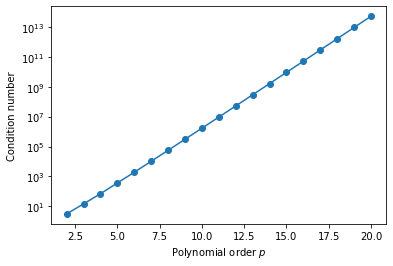

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Quick function to create a mass matrix M based on the monomial basis functions.
def mass_monomials(n):
    return np.fromfunction(
        np.vectorize(lambda i, j: (2.0 / (i+j+1)) if (i+j) % 2 == 0 else 0.0), 
        (n,n)
    )

# Consider polynomials ranging between 1 and 20 inclusive.
orders = range(2, 21)

# Compute the condition number of the mass matrix for each order.
condition_monomial = [ np.linalg.cond(mass_monomials(i)) for i in orders ]

# Plot the output on a semi-log scale.
plt.semilogy(orders, condition_monomial, 'o-')
plt.xlabel('Polynomial order $p$')
plt.ylabel('Condition number')
plt.show()

As we can see, the growth in condition number here is quite alarming! This has pretty severe consequences for the numerical stability of being able to invert matrices using this basis, even for relatively low polynomial orders. Instead therefore, we could consider an alternative set of basis functions, such as the [Legendre polynomials](https://en.wikipedia.org/wiki/Legendre_polynomials) $L_p(\xi)$. Since these are orthogonal, we have the relationship that

$$
[\mathbf{M}]_{ij} = \delta_{ij} \frac{2}{2i+1}
$$

where $\delta_{ij}$ is the Kronecker delta. This diagonality property will clearly lead to more favourable conditioning, as we can see from a quick numerical experiment akin to the one above:

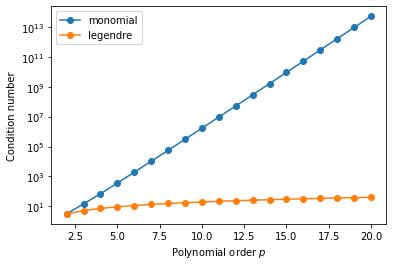

In [2]:
%matplotlib inline

# Compute a mass matrix of degree n-1 using the Legendre basis.
def mass_legendre(n):
    return np.diag(2.0/(2*np.arange(n)+1))

# Compute the condition number
condition_legendre = [ np.linalg.cond(mass_legendre(i)) for i in orders ]

plt.semilogy(orders, condition_monomial, 'o-', label='monomial')
plt.semilogy(orders, condition_legendre, 'o-', label='legendre')
plt.legend()
plt.xlabel('Polynomial order $p$')
plt.ylabel('Condition number')
plt.show()

This simple demonstration clearly demonstrates the need for a judicious choice of our underlying basis functions.

# Evaluating integrals and derivatives

Although we can analytically calculate the entries of the mass matrix in this simplified setting, in general this will not be the case:

- even in this simple setting, we still need to compute the right hand side inner product $(f,v)$ for an arbitrary function $f$;
- going to arbitrary elements in higher dimensions instead of a simple interval $[-1,1]$ makes these expressions impossible to calculate analytically in practice.

We therefore require a method of numerically computing integrals; in other words, we need a set of _quadrature rules_ for this problem. In a general quadrature scheme, given a set of $Q$ points $\{\hat{\xi}_q\}_{q=1}^Q \subset[-1,1]$ with associated weights $\{w_q\}$, we can approximate the integral of a function $g$ via the summation

$$
\int_{-1}^1 g(\xi)\,\mathrm{d}\xi \approx \sum_{q=1}^Q w_q g(\hat{\xi}_q) \label{eq:quad}
$$

Simple quadrature rules, such as the trapezium rule, could in theory be used for approximation purposes, but with a significant reduction in accuracy. However, since in our case we know _a priori_ that $g$ is a polynomial function, we can leverage [_Gaussian quadrature_](https://en.wikipedia.org/wiki/Gaussian_quadrature) to perform optimal integration.

## Gaussian quadrature

In Gaussian quadrature, points and weights are chosen optimally, so that a selection of $Q$ Gauss points enables the exact integration of polynomials up to total degree $2Q-1$. Since the entries of our mass matrix are integrals of the product of two polynomial functions of degree at most $P$, each integrand will be a polynomial of degree at most $2P$. This means that we can analytically compute the entries of this matrix via the representation of the basis functions using $P+1$ Gauss points.

The exact methods to determine optimal points and weights are somewhat beyond the scope of this short tutorial. To this end, we will use Nektar++, which contains  routines to generate quadrature for a wide variety of point distributions.

### Evaluating Gaussian quadrature in Nektar++

In this section, we'll use the Python interface to Nektar++ to access and evaluate Gaussian quadrature rules. Nektar++ is composed of several libraries, all of which serve a purpose in the definition of the broader spectral element method. The base library is a general-purpose utility library called `LibUtilities`, which serves the purpose of providing various utility functions within the framework:

- providing access to sets of quadrature rules and basis functions;
- performing elementary I/O operations; 
- provide a consistent interface to external libraries such as FFTW;
- handle low-level memory usage, etc.

For this tutorial we just want some quadrature rules and basis functions! To get this we need to use a few classes from Nektar++:

- A `PointsType` is a simple enumerator which describes the various distributions of quadrature points available in Nektar++.
- A `PointsKey` is a concrete definition of a distribution of points: it combines a `PointsType` with the desired number of points in a distribution.
- Given a `PointsKey`, you can request a set of points using the `Points` class. The `Points.Create` function takes a `PointsKey` and returns a `Points` object. This is a common [design pattern](https://en.wikipedia.org/wiki/Factory_method_pattern) in Nektar++, as we shall see in the following sections.
- The `Points` object that is returned contains various functions that allow you to extract properties of that points distribution, such as the point locations and their weights.

In practice this runs as follows:

In [3]:
from NekPy.LibUtilities import PointsKey, PointsType, Points

def gauss_points(n):
    # Create a PointsKey for a set of Gauss points. (Hint: in Jupyter, you can use the 'tab'
    # key for autocompletion after you type `PointsType.` to see available options).
    pkey_gauss = PointsKey(n, PointsType.GaussGaussLegendre)

    # Generate the set of Gauss points.
    return Points.Create(pkey_gauss)

# Throughout the rest of the tutorials, we'll use this num_points parameter to control
# polynomial order. If you want to run at different orders, you can change this variable
# and re-run all cells.
num_points = 5

# Create the Gauss points object.
points_gauss = gauss_points(num_points)

# Get the underlying array that contains the points, and the array that contains the
# weights, which are standard NumPy arrays.
z = points_gauss.GetZ()
w = points_gauss.GetW()

We can now use these points to evaluate some integrals. Since we have $Q=5$ points in the example above, this should allow us to compute the exact value any integrand which is a polynomial of up to degree $2Q-1 = 9$. To test this, let's numerically evaluate

$$
\int_{-1}^1 \xi^9+2\xi^2 \, \mathrm{d}\xi = \frac{4}{3} \quad\text{ and }\quad \int_{-1}^1 \xi^{10}+2\xi^3\, \mathrm{d}\xi = \frac{2}{11}.
$$

To do this, we just need to compute the summation \eqref{eq:quad} above, which is just the dot product of the weights array `w` together with the function evaluated at each quadrature point `z`.

In [4]:
# Evaluate the integrals above numerically, and compare them to their exact values.
abs(np.dot(z**9 + 2*z**2, w) - 4.0/3.0), abs(np.dot(z**10 + 2*z**3, w) - 2.0/11.0)

(2.220446049250313e-16, 0.0029318124556220737)

We can clearly see that whilst integration at $Q=5$ gives us an exact evaluation of this term to machine precision, for an order 10 polynomial we now get a non-zero integration error owing to insufficiently many quadrature points.

### Task 1: Investigating Gauss-Lobatto quadrature

Gauss points have one disadvantage when viewed in the context of their use in spectral elements: they do not contain the endpoints of the interval. The ability to examine the solution field at the endpoints of the interval by simply reading a value, rather than evaluating a summation to compute the endpoint values, can be computationally advantageous in certain instances.

To this end, in this task you should investigate an alternative set of _Gauss-Lobatto_ points. These are once more chosen optimally, but with the additional constraint that the first quadrature point location is at $\hat{\xi}_1 = -1$, whilst the last is at $\hat{\xi}_Q = 1$. This is convenient, but comes at an additional cost: the maximum order of integration reduces from $2Q-1$ for Gauss points to $2Q-3$ for Gauss-Lobatto points.

In the cell below:

1. Write a `gauss_lobatto_points` function, akin to the `gauss_points` function above, that uses Nektar++ to generate a distribution of Gauss-Lobatto points. **Hint:** you should use `PointsType.GaussLobattoLegendre` in the `PointsKey`.
2. Validate that the integration rule above is valid by integrating the polynomial $\xi^6$ using $Q=4$, $Q=5$ and $Q=6$.

In [5]:
def gauss_lobatto_points(n):
    pkey_gauss = PointsKey(n, PointsType.GaussLobattoLegendre)
    return Points.Create(pkey_gauss)

# For each quadrature order, create the Gauss points and then integrate \xi^6 numerically.
# You should see that the error at Q=5 and Q=6 is zero, whilst at Q=4 is non-zero. This is 
# what we expect: our polynomial is order 6. At Q=4 we can only therefore integrate
# polynomials up to order 2Q-3 = 5; at Q=5 this maximum order is 2Q-3 = 7.
for Q in range(4,7):
    gll_pts      = gauss_lobatto_points(Q)
    gll_z, gll_w = gll_pts.GetZW()
    print("Error at Q = {:d}: {:.4}".format(Q, np.abs(np.dot(gll_z**6, gll_w) - 2.0/7.0)))

Error at Q = 4: 0.06095
Error at Q = 5: 0.0
Error at Q = 6: 1.665e-16


### Task 2: Integrating in arbitrary intervals

Although Gaussian quadrature is constrained to the interval $[-1,1]$, we can still integrate in any arbitrary interval via a coordinate transformation between $[-1,1]$ and that interval. For an interval $[a,b]$ with a coordinate $x\in[a,b]$, define the mapping $\chi:[-1,1]\to[a,b]$ by

$$
x = \chi(\xi) = \frac{1-\xi}{2}a + \frac{1+\xi}{2}b \quad \Rightarrow \quad \frac{\mathrm{d}x}{\mathrm{d}\xi} = \tfrac{1}{2}(b-a) \quad\Rightarrow\quad \mathrm{d}x = \tfrac{1}{2}(b-a) \,\mathrm{d}\xi.
$$

Then the integral of a function $g(x)$ over $[a,b]$ can be written as

$$
\int_a^b g(x)\, \mathrm{d}x = \tfrac{1}{2}(b-a)\int_{-1}^1 g(\chi(\xi))\, \mathrm{d}\xi \approx \tfrac{1}{2}(b-a) \sum_{q=1}^Q w_q g(\chi(\hat{\xi}_q)).
$$

Using this expression, in the cell below, write a function called `integrate_interval` that takes as arguments a function to integrate, the interval range $a$ and $b$, and the number of Gauss points $Q$ to use for integration, then returns the approximate integral. For example you might call this `integrate_interval` to evaluate the integral $\int_1^2 x^2\,\mathrm{d}x$ using 10 Gauss points as follows:

```python
integrate_interval(lambda x: x**2, 1, 2, 10)
```

Using this function, calculate $\int_0^{\pi/2} \sin x\, \mathrm{d}x = 1$ for $2\leq Q\leq 7$, and plot the error versus $Q$ on semi-log axes. In using Gaussian quadrature we are essentially approximating the smooth function $\sin x$ with polynomials of order $Q-1$. The error $\varepsilon$ will therefore be proportional to $\varepsilon\propto C^Q$. Therefore, plotting $\log\varepsilon$ versus $Q$ should asymptotically give a straight line, since by taking the log of the error relationship we have $\log\varepsilon\propto Q\log C$.

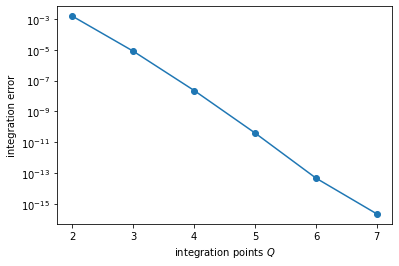

In [6]:
%matplotlib inline

def integrate_interval(func, a, b, Q):
    # Get our Gauss points and weights
    gauss_pts = gauss_points(Q)
    z, w = gauss_pts.GetZW()
    
    # Compute x-locations from the \chi mapping.
    x = 0.5*(1-z) * a + 0.5*(1+z) * b
    
    # Evaluate func at the x-locations, dot with the weights, and multiply.
    # by the Jacobian.
    return 0.5*(b-a) * np.dot(func(x), w)

int_errors = [ np.abs(integrate_interval(np.sin, 0, np.pi/2, Q) - 1.0) for Q in range(2,8) ]
plt.semilogy(range(2,8), int_errors, 'o-')
plt.xlabel('integration points $Q$')
plt.ylabel('integration error')
plt.show()

## Computing derivatives

In a similar manner to the integral quantities above, we also require the ability to numerically differentiate: for example, in the calculation of the Laplacian matrix each entry is of the form

$$
[\mathbf{L}]_{ij}\int_{-1}^1 \frac{\mathrm{d}\phi_i}{\mathrm{d}\xi} \frac{\mathrm{d}\phi_j}{\mathrm{d}\xi} \, \mathrm{d}\xi
$$

Again, although for this simple case we could conceivably compute analytic derivatives for the basis functions, in practice this is not ideal. Instead, we can make the following observation: given a polynomial $g(\xi)$ that is represented at each quadrature point $\hat{\xi}_q$, we may rewrite the polynomial as an expansion of  [Lagrange interpolant polynomials](https://en.wikipedia.org/wiki/Lagrange_polynomial) $\ell_q(\xi)$ so that

$$
g(\xi) = \sum_{q=0}^{Q-1} g(\hat{\xi}_q) \ell_{q}(\xi), \quad \text{ where } \quad \ell_q(\xi) = \prod_{0\leq m\leq {Q-1}, m\neq q} \frac{\xi-\xi_m}{\xi_q-\xi_m}
$$

Then we can compute the derivative of $g$ by taking the derivative of the summation above, i.e.

$$
\frac{\mathrm{d}g}{\mathrm{d}\xi}(\xi) = \sum_{q=0}^{Q} g(\hat{\xi}_q) \frac{\mathrm{d}\ell_{q}}{\mathrm{d}\xi}(\xi)
$$

In particular, we are interested in computing the derivative of $g$ at each quadrature point; i.e. we wish to calculate the vector $\mathbf{g}' = \{ g'(\hat{\xi}_q) \}_{q=0}^{Q-1} $ given the vector $\mathbf{g} = \{ g(\hat{\xi}_q) \}_{q=0}^{Q-1} $. According to the previous summation, this can be expressed as a matrix-vector product $\mathbf{g}' = \mathbf{D}\mathbf{g}$, where the _derivative matrix_ $\mathbf{D}$ is given by

$$ 
[\mathbf{D}]_{ij} = \frac{\mathrm{d}\ell_{j}}{\mathrm{d}\xi} (\hat{\xi}_i)
$$

which can be readily computed using known properties of the Lagrange interpolants.

### Getting the derivative matrix in Nektar++

Given our `Points` object, we can very easily compute the derivative matrix using the `GetD` function. Let's test our ability to compute derivatives by taking a known polynomial $g(\xi) = \xi^4+2\xi^3+2\xi$, which should have an analytic derivative $g'(\xi) = 4\xi^3 + 6\xi^2 + 2$.

In [7]:
# Get the derivative matrix.
deriv_matrix = points_gauss.GetD()

# Compute the derivative of our function.
deriv_poly = np.matmul(deriv_matrix, z**4 + 2 * z**3 + 2 * z)

# Check that we have the analytic answer to machine precision.
np.allclose(deriv_poly, 4*z**3 + 6*z**2 + 2)

True

### Task 3: Derivative of a function on an arbitrary interval

Following on from task 2, let's consider taking the derivative of a function $g(x)$ defined on an arbitrary interval $[a,b]$. To use our derivative matrix we need to project the function onto $[-1,1]$ and then apply the chain rule. In particular, we note that

$$
\frac{\mathrm{d}g}{\mathrm{d}x} = \frac{\mathrm{d}\xi}{\mathrm{d}x} \left. \frac{\mathrm{d}g}{\mathrm{d}\xi} \right|_{\xi = \chi^{-1}(x)} = \frac{2}{b-a}\left. \frac{\mathrm{d}g}{\mathrm{d}\xi} \right|_{\xi = \chi^{-1}(x)} \quad\Rightarrow\quad \mathbf{g}' \approx \frac{2}{b-a} \mathbf{D}\mathbf{g},
$$

where $\mathbf{g} = \{ g(\chi^{-1}(\hat{\xi}_q)) \}_{q=1}^Q$. Using this expression, in the cell below, write a function called `differentiate_interval` that takes as arguments a function to differentiate, the interval range $a$ and $b$, and the number of Gauss points $Q$ to use for differentiation. This should return a tuple containing:

- the Gauss points projected into the interval $[a,b]$ under $\chi$;
- the derivative of the function

For example you might use `integrate_interval` to differentiate $\sin x$ in $[0,2\pi]$ using $Q=50$ points, and then plot the result, using

```python
deriv_x, deriv_sin = differentiate_interval(np.sin, 0, 2 * np.pi, 50)
plt.plot(deriv_x, deriv_sin, 'o', label='approx')
```

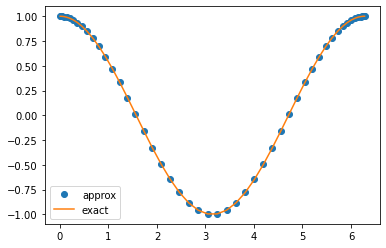

In [8]:
%matplotlib inline

def differentiate_interval(func, a, b, Q):
    gauss_pts = gauss_points(Q)
    z         = gauss_pts.GetZ()
    deriv     = gauss_pts.GetD()
    x         = 0.5*(1-z) * a + 0.5*(1+z) * b
    return (x, np.matmul(deriv, func(x)) * 2.0 / (b-a))

deriv_x, deriv_sin = differentiate_interval(np.sin, 0, 2 * np.pi, 50)
plt.plot(deriv_x, deriv_sin, 'o', label='approx')
plt.plot(deriv_x, np.cos(deriv_x), label='exact')
plt.legend()
plt.show()

## Defining a basis

Finally, we need the ability to define a basis that will be evaluated at a set of quadrature points. To define our basis functions, we can again utilise the `LibUtilities` library. The concept is quite similar to the definition of a `Points` object; we need:

- a `BasisType` which defines the type of basis;
- the number of modes in the expansion, which is one higher than the polynomial order $P$;
- a `PointsKey` which defines the points that the basis will be evaluated at;
- a `BasisKey`, which again is the concrete definition of the basis: it combines the `BasisType`, the number of modes, and the `PointsKey`

Using this, let's set up a `Basis` object for our Gauss points object. Since we used $Q=5$ Gauss points, this is capable of integrating polynomials up to order $P=8$ exactly. This means that we can exactly integrate a mass matrix of expansions of order $4$, so we can create a basis with 5 modes.

In [9]:
from NekPy.LibUtilities import BasisKey, BasisType, Basis

def legendre_basis(n):
    # Create a points key.
    pkey_gauss = PointsKey(n, PointsType.GaussGaussLegendre)

    # Create a BasisKey for these points.
    bkey_gauss = BasisKey(BasisType.Legendre, n, pkey_gauss)

    # Create the basis.
    return Basis.Create(bkey_gauss)

basis_legendre = legendre_basis(num_points)

Basis objects contain all the information from their `Points` class, so we can call e.g. `basis_legendre.GetZ()` to get the points distribution. However, we now have access to a basis defined at these points, which can be extracted using the `GetBdata` function. This is a matrix $\mathbf{B}$ of size $(P+1)\times Q$, where each entry $\mathbf{B}_{pq} = \phi_p(\hat{\xi}_q)$ expresses the desired basis $\phi_p$ at a quadrature point $\hat{\xi}_q$. We can use this to visualise our basis functions, e.g.:

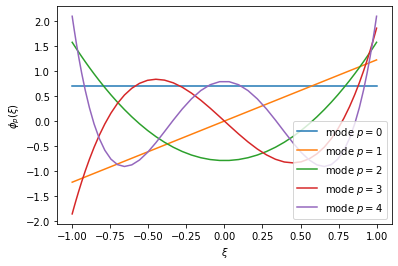

In [10]:
%matplotlib inline

# Create a Legendre basis at a larger number of Gauss points for visualisation
# purposes
basis_legendre_viz = Basis.Create(
    BasisKey(BasisType.Legendre, 5, PointsKey(50, PointsType.GaussGaussLegendre)))
bdata_viz = basis_legendre_viz.GetBdata().reshape((5, 50))
z_viz = basis_legendre_viz.GetZ()

for p in range(5):
    plt.plot(z_viz, bdata_viz[p,:], label='mode $p=%d$' % p)

plt.xlabel(r'$\xi$')
plt.ylabel(r'$\phi_p(\xi)$')
plt.legend()
plt.show()

# Solving the Helmholtz equation

Now we're equipped with basic knowledge on Gaussian integration and the weak formulation, we theoretically have enough knowledge to solve our original problem of solving the Helmholtz equation in a single element. To do this, we're going to need to be able to test whether our discretisation works (or not!). For this, we need a solution to the Helmholtz equation. Instead of trying to find solutions, instead we can simply manufacture them: considering our original equation

$$
\nabla^2 u - \lambda u = f,
$$

and setting $\lambda = 1$, if we specify a function $u(\xi)$ that naturally obeys our boundary conditions, then we can define $f(\xi)$ corresponding to this known solution by evaluating the left hand side. For example, if we select $u(\xi)=\cos(\pi\xi)$ then $\partial_\xi u(\pm 1) = -\pi\sin(\pm\pi) = 0$. Evaluating the left hand side gives

$$
f(\xi) = -(\pi^2+\lambda) \cos(\pi \xi)
$$

## Doing it ourselves

In theory we have sufficient knowledge now to code this ourselves without much assistance from Nektar++. To do this we need to generate our Helmholtz matrix, and then compute the right hand side. 

### Generating the Helmholtz matrix

The first step is to compute the matrix $\mathbf{L}+\lambda\mathbf{M}$, from the Laplacian and mass matrices respectively. For this, let's use a Legendre expansion of order $P$ equipped with $Q$ Gauss points. In general, the mass matrix will have integrands whose degree is $2P$, which would require $Q=P+2$ points to integrate exactly. However in this particular setting, we know the mass matrix entries analytically; since the Laplacian matrix has entries whose integrand is of total degree $2P-2$ owing to using the derivatives of the basis functions. Therefore, we can simply select $Q=P+1$ Gauss points to integrate this exactly.

With this in mind, let's write a function that will compute our Helmholtz matrix.

In [27]:
def helmholtz_legendre(n, lamb):
    # Get the Legendre basis. 
    basis = legendre_basis(n)

    # Since we need the derivative of the basis functions, we can use the GetDbdata
    # function. This is an array of size (P+1) x Q, where rows correspond to each basis
    # function and columns correspond to the evaluation of the basis function at the
    # quadrature points. This is the same concept as the GetBdata function, just with the
    # derivatives instead of the basis functions.
    dbdata = basis.GetDbdata().reshape(n, n)
    
    # Get the integration weights for our quadrature.
    w = basis.GetW()

    # Compute the Laplacian matrix. This is simply the multiplication of the two derivatives,
    # followed by a summation over the weights.
    laplacian = np.array([ 
        [ sum(dbdata[i,:] * dbdata[j,:] * w) for j in range(n) ]
        for i in range(n)
    ])
    
    # Finally we can add on the mass matrix entries to the diagonal of the matrix.
    # A technical point here is that in Nektar++, the Legendre polynomials are
    # orthonormalised so that their mass matrix is the identity matrix. This means
    # that technically, our mass_legendre() function is not consistent with the
    # definition here. To solve this, we simply add on the identity matrix multiplied 
    # by the constant lambda.
    laplacian[np.diag_indices_from(laplacian)] += lamb
    return laplacian

helm_matrix = helmholtz_legendre(num_points, 1.0)

### Computing the right-hand side inner product

Now we have the left-hand side of the equation sorted, we need to compute our right-hand side inner product vector, where each entry is

$$
[\mathbf{f}]_i = \int_{-1}^1 f(\xi) \phi_i(\xi) \,\mathrm{d}\xi
$$

In [12]:
def rhs_forcing(n, lamb):
    basis = legendre_basis(n)

    # Get the points distribution.
    z, w = basis.GetZW()
    
    # Compute the forcing function.
    f = (np.pi**2 + lamb) * np.cos(np.pi*z)
    
    # Get the basis functions at the quadrature points using the GetBdata function.
    bdata = basis.GetBdata().reshape(n,n)
    
    # Evaluate each entry of the RHS variable
    return np.array([ sum(bdata[i,:] * f * w) for i in range(n) ])

rhs = rhs_forcing(num_points, 1.0)

### Solving the equation

Finally, we're good to go! We can solve for our unknown coefficients using NumPy's `solve` routine from the `linalg` module.

In [13]:
def do_solve(n, lamb):
    return np.linalg.solve(helmholtz_legendre(n, lamb), rhs_forcing(n, lamb))

coeffs = do_solve(num_points, 1.0)

### Visualising the solution

Of course, we now have some coefficients, but we need to be able to visualise them. For this we can evaluate the original summation at the very top of this tutorial, i.e. at any point $\xi\in[-1,1]$, we can compute

$$
u(\xi) = \sum_{p=0}^P \hat{u}_p \phi_p(\xi)
$$

knowing that $\hat{u}_p$ is now stored in our `coeffs` array and $\phi_p$ are the Legendre functions. However, since we only have 5 quadrature points, this would look very rough and uneven! Therefore we need to evaluate at a much larger range of points, and we need the basis functions evaluated at those points.

To help us with this, we can again use Nektar++ to generate points at a larger set of visualisation points. For this purpose we can use the `PolyEvenlySpaced` points type, which creates an evenly-spaced distribution of points in the range $[-1,1]$. If we create a `Basis` on this set of points, then we can get everything we need to evaluate our expression and compare it to the exact solution.

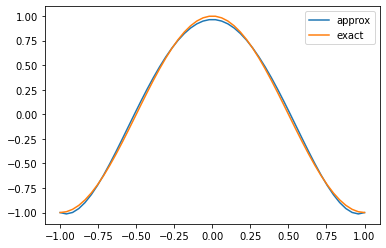

In [14]:
%matplotlib inline

def visualise(coeffs):
    # Get the number of modes from our coeffs array.
    n = len(coeffs)

    # Create a PointsKey that we'll use to evaluate the solution at 50 evenly-spaced points.
    pkey_viz = PointsKey(50, PointsType.PolyEvenlySpaced)
        # Create a Legendre basis on this 
    basis_viz = Basis.Create(BasisKey(BasisType.Legendre, n, pkey_viz))

    # z_viz and bdata will represent our evenly-spaced points, and the basis functions represented
    # on those points.
    z_viz = basis_viz.GetZ()
    bdata = basis_viz.GetBdata().reshape(n, 50)    
    
    # Finally, plot the solution!
    plt.plot(z_viz, np.dot(coeffs, bdata), label='approx')
    plt.plot(z_viz, np.cos(np.pi*z_viz), label='exact')
    plt.legend()
    plt.show()

visualise(coeffs)

## Doing it with Nektar++

Now that we've seen that we can solve things by setting things up by hand, let's simplify the process by using Nektar++. To do this, we're going to go up another level in Nektar++'s framework to the `StdRegions` library. This library provides classes that live under a base class of `StdExpansion`, which are designed to represent our expansion of the form

$$
u(\xi) = \sum_{p=0}^P \hat{u}_p \phi_p(\xi).
$$

on standard/reference elements, such as the interval $[-1,1]$.

### Creating an expansion

To create a `StdExpansion` object, we need a basis key that denotes the choice of basis function. We already have this! To tell Nektar++ we would like to use a segment $\Omega=[-1,1]$, we need to create a `StdSegExp` object -- or 'standard segment expansion'. This takes only a single argument, the basis key.

In [15]:
from NekPy.StdRegions import StdSegExp

def create_stdexp(n):
    # Create a standard segment.
    return StdSegExp(legendre_basis(n).GetBasisKey())
    
segment = create_stdexp(num_points)

Our standard expansion now allows us to perform some elementary operations, such as creating matrices. But before we get to this, to familiarise ourselves with the usage of this class, let's consider another example: visualising the basis functions.

In our expansion we have two representations: the coefficient space $\{\hat{u}_p\}_{p=0}^P$, and the physical space where the function is evaluated at the quadrature points. To get between these two spaces, `StdRegions` objects have `FwdTrans` and `BwdTrans` functions that perform 'forward' transformations (from physical to coefficient space) and 'backward' transformations (from coefficient to physical space). Therefore, if we want to visualise the $n$-th basis function, we can simply pass in a coefficient vector $\{\hat{u}_p\}$ into the `BwdTrans` routine, with

$$
\hat{u}_p = \delta_{pn} = \begin{cases}
1, & p = n, \\
0, & \text{otherwise}.
\end{cases}
$$

Then our expansion becomes

$$
u(\xi) = \sum_{p=0}^P \hat{u}_p\phi_p(\xi) = \sum_{p=0}^P \delta_{pm} \phi_p(\xi) = \phi_m(\xi)
$$

So that we can view these basis functions at more than only our five Gauss points, we'll use our visualisation basis, as in the example above. The cell below implements this logic, and prints out our 5 Legendre modes.

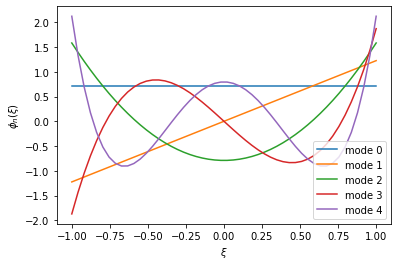

In [16]:
%matplotlib inline

def viz_basis(n):
    # Create a points key for 50 evenly-spaced points. We can use 
    pkey_viz = PointsKey(50, PointsType.PolyEvenlySpaced)

    # Create an expansion on these points. This is pretty terrible for
    # actual integration, but we are just using this for visualisation purposes.
    segment_even = StdSegExp(BasisKey(BasisType.Legendre, n, pkey_viz))

    # Create some storage for our coefficient vector.
    coeffs = np.zeros(n)

    # Get the points of our expansion (the 50 evenly-spaced points above).
    xi     = segment_even.GetBasis(0).GetZ()

    # Simple loop: let's set coeffs[i] = 1.0 at each entry and then perform a
    # backwards transform. This will set every coefficient to 0, asides from at
    # entry i.
    for i in range(num_points):
        coeffs[i] = 1.0
        plt.plot(xi, segment_even.BwdTrans(coeffs), '-', label='mode %d' % i)
        coeffs[i] = 0.0

    plt.xlabel(r'$\xi$')
    plt.ylabel(r'$\phi_n(\xi)$')
    plt.legend()
    plt.show()

viz_basis(num_points)

### Task 4: Compute integrals and derivatives

As another bit of practice with our new `StdSegExp` object, try calling the `Integral` function to integrate the function $g(\xi) = \xi^2$, and the `PhysDeriv` function to compute its derivative. Both of these functions take as their arguments $g$ evaluated at the quadrature points; the integral should be $\tfrac{2}{3}$ whilst the derivative is the linear function $g'(\xi)=2\xi$.

In [34]:
# Compute g at the quadrature points.
g = z ** 2

# Compute the integral of g and test whether the derivative is close to the function 2z.
segment.Integral(g), np.allclose(segment.PhysDeriv(g), 2 * z)

(0.6666666666666667, True)

### Creating a Helmholtz matrix

Let's now move on to creating a Helmholtz matrix. Nektar++ elements naturally provide a method to compute elemental matrices, being a core part of the formulation. The process to generate a matrix follows the same pattern as our points and basis classes: i.e. we create a `StdMatrixKey` which, when passed to the `GenMatrix` routine, gives us a matrix in return that corresponds to that key.

Additionally, certain matrices require additional parameters in order to be generated. For the Helmholtz problem, we need to pass the value of $\lambda$ through to the creation routine. This is achieved through the use of a _factors map_, represented in Nektar++ by a `ConstFactorMap`.

This is probably easier to be seen in code, rather than to be explained, which we outline in the cell below.

In [17]:
from NekPy.StdRegions import StdMatrixKey, MatrixType, ConstFactorMap, ConstFactorType

def helmholtz_nektar(n, lamb):
    # Create our factors map. This is basically akin to a Python dictionary: keys are
    # mapped to values.
    factors = ConstFactorMap()
    
    # We tell the map that our Lambda constant should be set to whatever value is 
    # passed into this function.
    factors[ConstFactorType.FactorLambda] = lamb

    # Create a standard segment of the right order.
    segment = create_stdexp(n)
    
    # Construct a matrix key: we need to pass in the matrix, the shape of the element,
    # the element itself and finally the factors map.
    mkey = StdMatrixKey(MatrixType.Helmholtz, segment.DetShapeType(), segment, factors)
    
    # Finally call the GenMatrix routine to generate our Helmholtz matrix.
    return segment.GenMatrix(mkey)

helm_nektar = helmholtz_nektar(num_points, 1.0)

We can additionally check that our matrix is identical to the one that we generated by hand earlier.

In [18]:
np.allclose(helm_matrix, helm_nektar)

True

### Computing the right-hand side inner product

The final step of the problem is to compute the right-hand side inner product. Since this is obviously a very well-used operator, we have a special function to compute this for us: the `IProductWRTBase` function. This accepts as input a function defined at the quadrature points, and returns as output the inner product of that function against each of our basis functions.

In [36]:
def rhs_forcing_nektar(n, lamb):
    segment = create_stdexp(n)
    z = segment.GetBasis(0).GetZ()
    return segment.IProductWRTBase((np.pi**2 + lamb) * np.cos(np.pi*z))

rhs_nektar = rhs_forcing_nektar(num_points, 1.0)

Again, we can validate that we get the same answer as in the `rhs` variable we computed before.

In [37]:
np.allclose(rhs_nektar, rhs)

True

### Solving and visualising the solution

It only remains to solve the problem once more and visualise the output. Solving is again straightforward using the `linalg.solve` routine:

In [21]:
def solve_nektar(n, lamb):
    return np.linalg.solve(helmholtz_nektar(n, lamb), rhs_forcing_nektar(n, lamb))

coeffs_nektar = solve_nektar(num_points, 1.0)

# Validate our solution is the same as before.
np.allclose(coeffs, coeffs_nektar)

True

We can visualise either the solution field at the Gauss quadrature points:

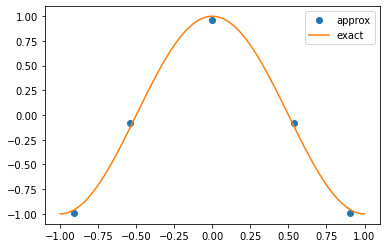

In [22]:
%matplotlib inline

def visualise_nektar_pts(coeffs):
    # Get the number of modes by examining the coefficients array.
    n = len(coeffs)
    
    # Create a segment, and get the quadrature points.
    segment = create_stdexp(n)    
    z = segment.GetBasis(0).GetZ()

    # Plot the obtained solution just at the Gauss points.
    plt.plot(z, segment.BwdTrans(coeffs_nektar), 'o', label='approx')

    # Plot the exact solution as a smooth function.
    xi = np.linspace(-1, 1, 100)
    plt.plot(xi, np.cos(np.pi*xi), label='exact')

    plt.legend()
    plt.show()
    
visualise_nektar_pts(coeffs_nektar)

Or alternatively, we can do the same as before and visualise at a larger number of points.

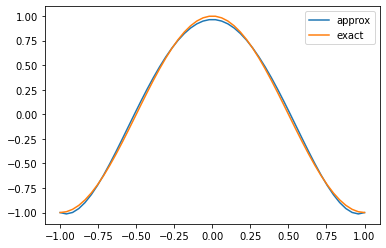

In [38]:
%matplotlib inline

def visualise_nektar(coeffs):
    # Get the number of modes by examining the coefficients array.
    n = len(coeffs)
    
    pkey_viz = PointsKey(50, PointsType.PolyEvenlySpaced)
    segment_viz = StdSegExp(BasisKey(BasisType.Legendre, n, pkey_viz))
    
    z = segment_viz.GetBasis(0).GetZ()

    # Plot the obtained solution just at the Gauss points.
    plt.plot(z, segment_viz.BwdTrans(coeffs), label='approx')
    plt.plot(z, np.cos(np.pi*z), label='exact')

    plt.legend()
    plt.show()
    
visualise_nektar(coeffs_nektar)

### Computing the $L^2$ error

Given access to a relatively complete range of functions in Nektar++, we can also use this opportunity to use other functions within the standard expansion object. For example, the discrete $L^2$ error can be computed by supplying the approximate and the exact solution evaluated at the quadrature points, for example

In [23]:
# We can also calculate the L2 error of the exact solution.
segment.L2(segment.BwdTrans(coeffs), np.cos(np.pi * z))

0.05082197088942998

### Task 4: Investigate the convergence order

In the cell below, write code that solves the Helmholtz problem for orders $1\leq p\leq 20$, then plot the $L^2$ error of the approximation on a log-log scale. Since our error should scale as $C^p$ we expect to see exponential convergence on this plot.

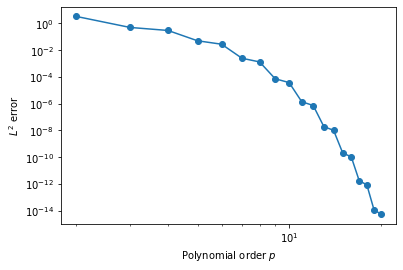

In [24]:
%matplotlib inline

def l2(n):
    segment = create_stdexp(n)
    z = segment.GetBasis(0).GetZ()
    return segment.L2(segment.BwdTrans(solve_nektar(n, 1.0)), np.cos(np.pi * z))

errors = [ l2(n) for n in range(2,21) ]
plt.loglog(range(2,21), errors, 'o-')
plt.xlabel('Polynomial order $p$')
plt.ylabel(r'$L^2$ error')
plt.show()

# End of the tutorial